In [185]:
from langchain_ollama import OllamaLLM
from langgraph.graph import START, StateGraph, MessagesState
from langchain_core.messages import HumanMessage, AIMessage, RemoveMessage, SystemMessage
from typing import Literal

In [186]:
chat = OllamaLLM(
    model="llama3.1:8b",
    temperature=0.5,
    num_predict=100
)

In [187]:
class State(MessagesState):
    summary:str

In [188]:
def ask_question(state: State) -> State:
    print("Current messages: " + state["messages"].__str__())

    question = "What is your question?"

    input_body = input(question)
    if input_body == "":
        input_body = "What is capital of Russia?"

    state["messages"].extend([
        AIMessage(question),
        HumanMessage(input_body)
    ])
    return state

In [189]:
def summarize_messages(state: State) -> State:

    new_conversation = ""
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"

    print("New conversation: " + new_conversation)

    summary_instructions = f''',
        Update the ongoing summary by incorporating the new lines of conversation below.",
        Build upon the previous summary rather than repeating it so that the result",
        reflects the most recent context and developments.

        Previous Summary:
        {state.get("summary", "")}

        New conversation:
        {new_conversation}
    '''

    print("Summary instructions: " + summary_instructions)

    summary = chat.invoke([HumanMessage(summary_instructions)])

    print("Chat summary: " + summary)

    remove_message = [RemoveMessage(id = i.id) for i in state["messages"][:]]

    print("Remove messages: " + remove_message.__str__())

    return State(summary=summary, messages=remove_message)

In [190]:
def chatbot(state: State) -> State:
    chat_request = []
    if state.get("summary", "") == "":
        chat_request = state["messages"]
    else:
        system_message = f'''
            Here's a quick question of what's been discussed so far:
            {state.get("summary", "")}
            Keep this in mind as your answer the next question.
        '''
        chat_request = [SystemMessage(system_message)] + state["messages"]

    print("Chat request: " + chat_request.__str__())
    response = chat.invoke(chat_request)
    print("Chat response: " + response.__str__())
    return State(messages = [response])

In [191]:
def ask_another_question(state: MessagesState) -> State:
    question = "Any further questions (yes/no)?"
    return State(messages = [AIMessage(question), HumanMessage(input(question))])

In [192]:
def routing_function(state: MessagesState) -> Literal["summarize_messages", "__end__"]:
    
    if state["messages"][-1].content == "yes":
        return "summarize_messages"
    else:
        return "__end__"

### Define the Graph

In [193]:
graph = StateGraph(MessagesState)

In [194]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("summarize_messages", summarize_messages)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_edge("summarize_messages", "ask_question")
graph.add_conditional_edges(source = "ask_another_question",
                            path = routing_function)

In [195]:
graph_compiled = graph.compile()

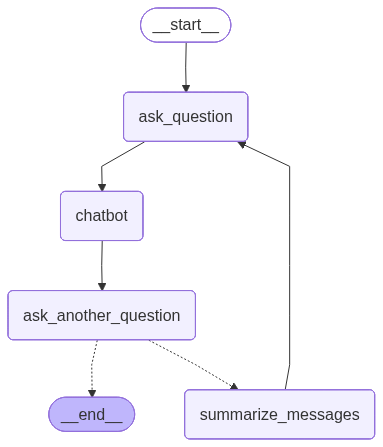

In [196]:
graph_compiled

### Test the Graph

In [197]:
graph_compiled.invoke(MessagesState(messages = []))

Current messages: []
Chat request: [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='94fc2619-c104-4062-88e5-bf0dd3dfb133'), HumanMessage(content='What is capital of Russia?', additional_kwargs={}, response_metadata={}, id='5e5c2e32-0109-4014-9d7e-6c8113c711fe')]
Chat response: The capital of Russia is Moscow.
New conversation: ai: What is your question?

human: What is capital of Russia?

human: The capital of Russia is Moscow.

ai: Any further questions (yes/no)?

human: yes


Summary instructions: ,
        Update the ongoing summary by incorporating the new lines of conversation below.",
        Build upon the previous summary rather than repeating it so that the result",
        reflects the most recent context and developments.

        Previous Summary:
        

        New conversation:
        ai: What is your question?

human: What is capital of Russia?

human: The capital of Russia is Moscow.

ai: Any further questions (yes/no)?

h

{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='414d482f-47ce-43ac-a3f7-f61ff6993052'),
  HumanMessage(content='When it was founded?', additional_kwargs={}, response_metadata={}, id='46fe59ad-d439-47a7-b57e-e3090bb7210a'),
  HumanMessage(content='Moscow, the capital of Russia, has a rich history dating back to 1147 when it was first mentioned in historical records. However, its origins date back even further, with archaeological findings indicating human presence in the area as far back as 800 BC. Would you like more information on this topic?', additional_kwargs={}, response_metadata={}, id='5b4ac546-dbfa-4b57-a415-282aa66ac707'),
  AIMessage(content='Any further questions (yes/no)?', additional_kwargs={}, response_metadata={}, id='8549ca99-2e31-416e-810e-ac6dcb42ff05'),
  HumanMessage(content='no', additional_kwargs={}, response_metadata={}, id='17ad519b-a78d-4957-bf7c-99c7a23024a0')]}